In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df=pd.read_csv(url)

print(df .head())
print(df.shape)
print(df.columns)
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [2]:
df = df.rename(columns={
"lifeExp": "life_expectancy",
"pop": "population",
"gdpPercap": "gdp_per_capita"
})
print(df.head())
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [3]:
print("Missing values in each column:")
print(df.isna().sum())
print ("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
country            0
year               0
population         0
continent          0
life_expectancy    0
gdp_per_capita     0
dtype: int64
Number of duplicate rows: 0


In [4]:
# Range of year
min_year = df['year'].min()
max_year = df['year'].max()
print(f"The year range in the dataset is from {min_year} to {max_year}.")

The year range in the dataset is from 1952 to 2007.


In [5]:
# number of countries and continents
num_countries = df['country'].nunique()
num_continents = df['continent'].nunique()
print(f"Number of unique countries: {num_countries}")
print(f"Number of unique continents: {num_continents}")

Number of unique countries: 142
Number of unique continents: 5


In [6]:
print("Average life expectancy:", df["life_expectancy"].mean())
print("Minimum life expectancy:", df["life_expectancy"].min())
print("Maximum life expectancy:", df["life_expectancy"].max())

Average life expectancy: 59.474439366197174
Minimum life expectancy: 23.599
Maximum life expectancy: 82.603


In [7]:
#grouping and counts
print (df["continent"].value_counts())

continent_summary = df.groupby("continent")[["life_expectancy","gdp_per_capita","population"]]. mean()
print(continent_summary)

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64
           life_expectancy  gdp_per_capita    population
continent                                               
Africa           48.865330     2193.754578  9.916003e+06
Americas         64.658737     7136.110356  2.450479e+07
Asia             60.064903     7902.150428  7.703872e+07
Europe           71.903686    14469.475533  1.716976e+07
Oceania          74.326208    18621.609223  8.874672e+06


In [8]:
#Comparision by latest year
latest_year = df["year"].max()
latest_df = df[df["year"] == latest_year].copy()
print("Latest year:", latest_year)
print(latest_df.head())
print(latest_df.shape)

Latest year: 2007
        country  year  population continent  life_expectancy  gdp_per_capita
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338
23      Albania  2007   3600523.0    Europe           76.423     5937.029526
35      Algeria  2007  33333216.0    Africa           72.301     6223.367465
47       Angola  2007  12420476.0    Africa           42.731     4797.231267
59    Argentina  2007  40301927.0  Americas           75.320    12779.379640
(142, 6)


/tmp/ipykernel_2811/3047797053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=continent_summary.index, y=continent_summary['life_expectancy'], palette='viridis')


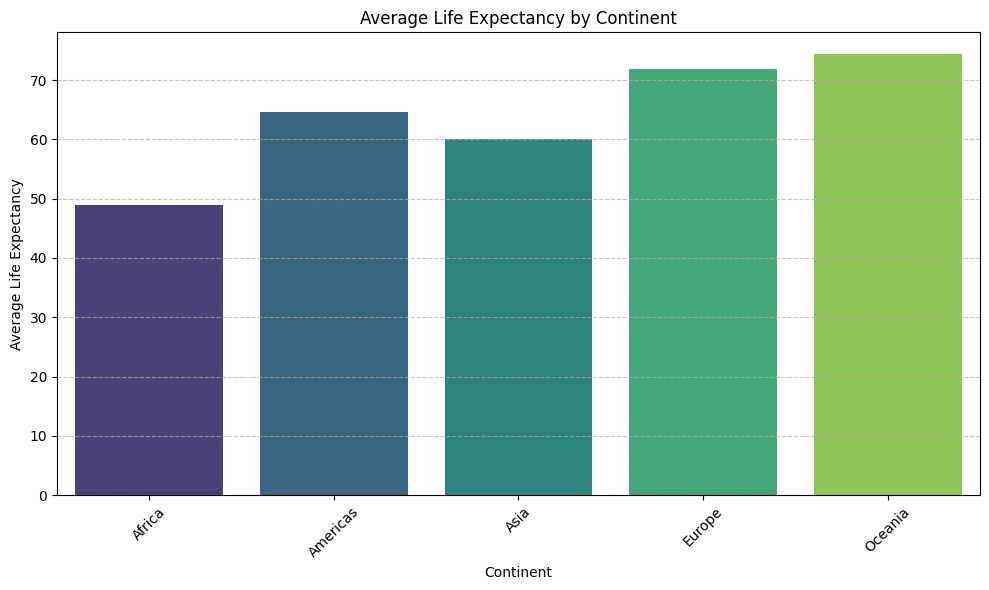

In [9]:
#bar chart of life expectancy by continent

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=continent_summary.index, y=continent_summary['life_expectancy'], palette='viridis')
plt.title('Average Life Expectancy by Continent')
plt.xlabel('Continent')
plt.ylabel('Average Life Expectancy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

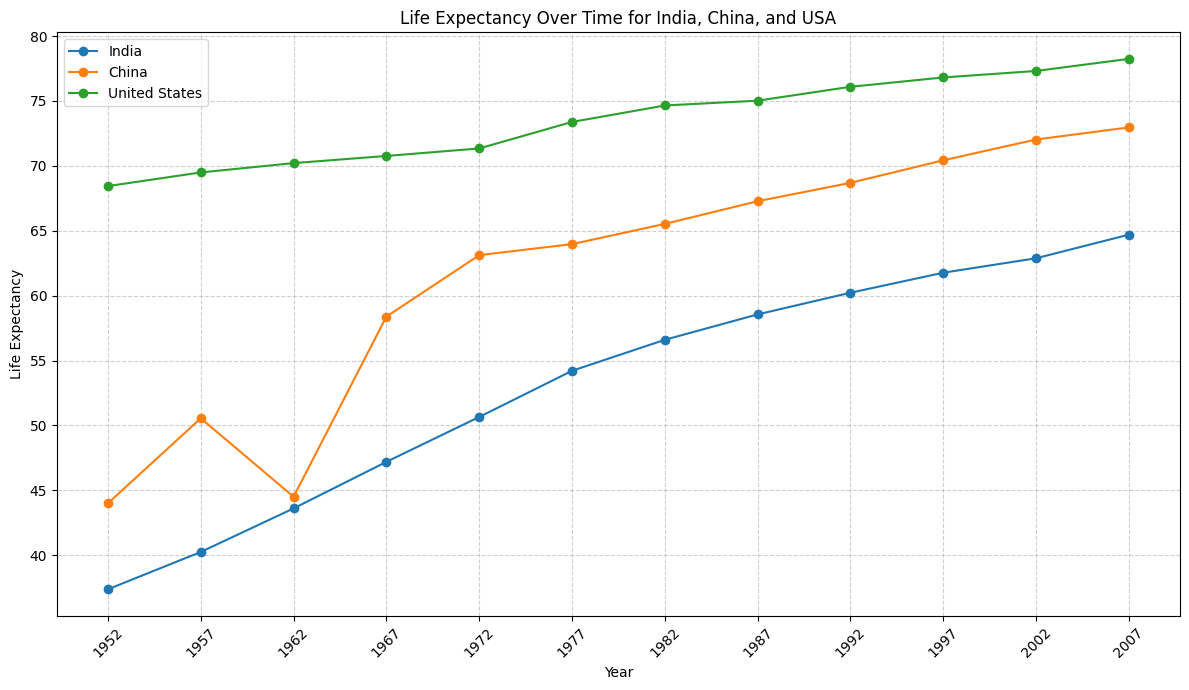

In [10]:
countries_to_plot = ['India', 'China', 'United States']
df_filtered = df[df['country'].isin(countries_to_plot)]

plt.figure(figsize=(12, 7))
for country in countries_to_plot:
    country_data = df_filtered[df_filtered['country'] == country]
    plt.plot(country_data['year'], country_data['life_expectancy'], label=country, marker='o')

plt.title('Life Expectancy Over Time for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df['year'].unique(), rotation=45)
plt.tight_layout()
plt.show()

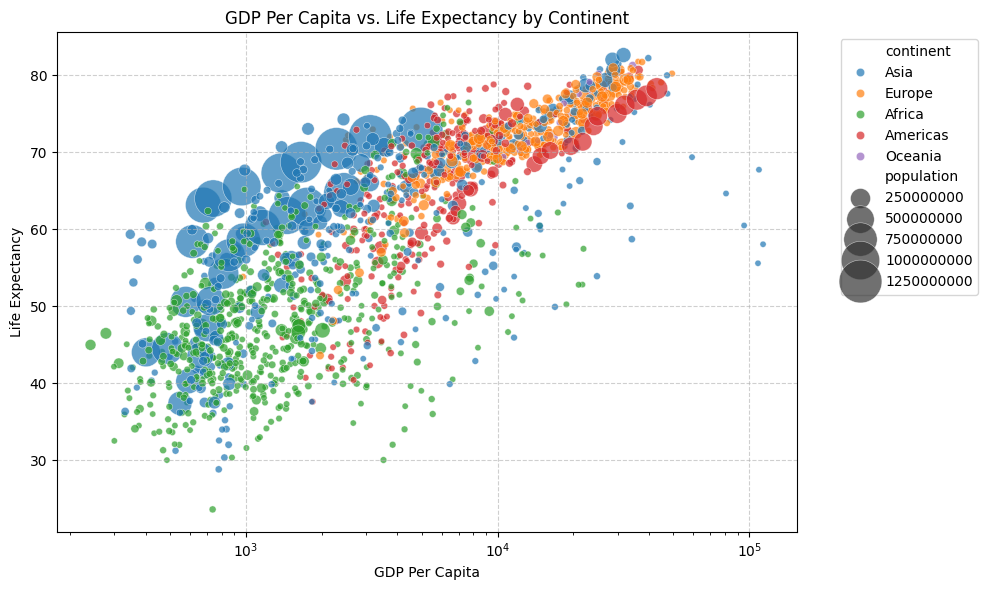

In [11]:
#scatter plot for gdp per capita vs life expentancy

plt.figure(figsize=(10, 6))
sns.scatterplot(x='gdp_per_capita', y='life_expectancy', hue='continent', size='population', data=df, sizes=(20, 1000), alpha=0.7)
plt.title('GDP Per Capita vs. Life Expectancy by Continent')
plt.xlabel('GDP Per Capita')
plt.ylabel('Life Expectancy')
plt.xscale('log') # Use a log scale for GDP to better visualize the distribution
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Key Insights from the Data Visualizations

Based on the exploratory data analysis and the generated charts, we can derive the following insights:

1.  **Life Expectancy by Continent (Bar Chart):**
    *   Europe and Oceania consistently show the highest average life expectancies, indicating better overall health and living conditions in these regions.
    *   Africa has the lowest average life expectancy, suggesting significant disparities in health outcomes compared to other continents.
    *   Americas and Asia fall in the middle, with life expectancies generally higher than Africa but lower than Europe and Oceania.

2.  **Life Expectancy Over Time for India, China, and USA (Line Plot):**
    *   All three countries (India, China, and the United States) have shown a general upward trend in life expectancy from 1952 to 2007, indicating global improvements in health and living standards.
    *   The United States consistently maintained a higher life expectancy throughout the period compared to India and China.
    *   China showed a significant increase in life expectancy, narrowing the gap with the United States over the decades.
    *   India also saw improvements, though its life expectancy remained the lowest among the three countries.

3.  **GDP Per Capita vs. Life Expectancy by Continent (Scatter Plot):**
    *   There is a clear positive correlation between GDP per capita and life expectancy: as GDP per capita increases, so does life expectancy. Countries with higher economic prosperity tend to have longer life spans.
    *   The use of a logarithmic scale for GDP per capita highlights this relationship even among countries with vastly different economic scales.
    *   Countries from the same continent tend to cluster together, illustrating regional similarities in economic development and health outcomes.
    *   Africa generally occupies the lower-left portion of the plot (low GDP per capita, low life expectancy), while Europe and Oceania are in the upper-right (high GDP per capita, high life expectancy).
    *   The size of the bubbles, representing population, shows that heavily populated countries like China and India have experienced growth in both GDP and life expectancy, moving towards the upper-right over time (though the plot itself is a snapshot, the underlying data would show this trend).